In [1]:
import numpy as np

In [2]:
import pandas as pd
from google.colab import drive

# mount drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/data/yellow_tripdata_2019-01.csv'

df = pd.read_csv(file_path)

df = df.sample(100000, random_state=42)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
1809713,2,2019-01-09 09:28:06,2019-01-09 09:31:43,1,0.52,1,N,164,234,1,4.5,0.0,0.5,1.06,0.0,0.3,6.36,NaN
211853,2,2019-01-02 07:29:10,2019-01-02 07:37:09,1,1.15,1,N,100,230,1,7.0,0.0,0.5,1.95,0.0,0.3,9.75,NaN
1425677,2,2019-01-07 15:55:27,2019-01-07 16:06:42,1,2.44,1,N,140,162,2,10.5,1.0,0.5,0.00,0.0,0.3,12.30,NaN
1769695,1,2019-01-09 06:52:41,2019-01-09 06:56:05,1,1.20,1,N,151,239,1,5.5,0.0,0.5,1.25,0.0,0.3,7.55,NaN
3889963,1,2019-01-17 08:50:24,2019-01-17 09:14:37,1,4.60,1,N,140,260,1,20.0,0.0,0.5,0.00,0.0,0.3,20.80,NaN


In [3]:
df.shape

(100000, 18)

In [4]:
df = df.dropna()

df = df[df['trip_distance'] > 0]
df = df[df['fare_amount'] > 0]
df = df[df['passenger_count'] > 0]


In [5]:
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
df['pickup_day'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek

df['trip_duration'] = (
    pd.to_datetime(df['tpep_dropoff_datetime']) -
    pd.to_datetime(df['tpep_pickup_datetime'])
).dt.total_seconds()/60

In [6]:
df[['trip_distance','pickup_hour','pickup_day','trip_duration','fare_amount']].head()

,trip_distance,pickup_hour,pickup_day,trip_duration,fare_amount
5695920,1.48,15,3,504.533333,9.0
5870746,2.33,8,4,16.866667,12.5
5976161,1.30,15,4,7.450000,7.5
7627537,2.23,21,3,16.933333,12.5
7377344,0.81,23,2,3.250000,4.5


In [7]:
fare_by_hour = df.groupby('pickup_hour')['fare_amount'].mean()

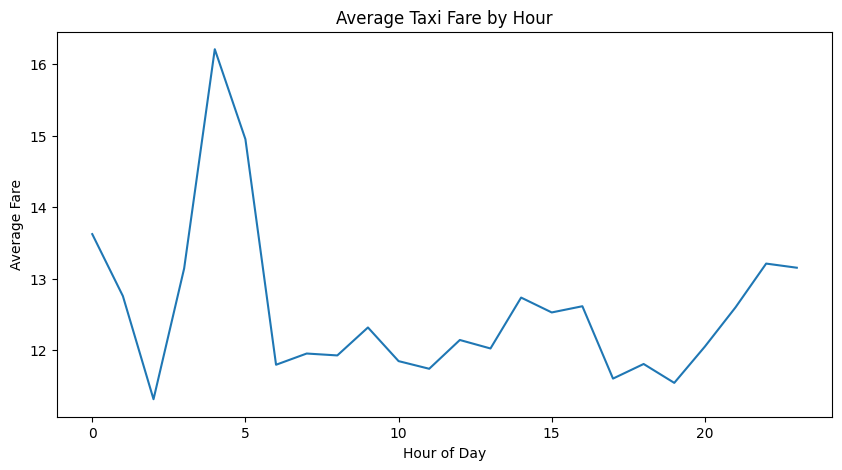

In [8]:
import matplotlib.pyplot as plt

fare_by_hour.plot(kind='line', figsize=(10,5))
plt.title("Average Taxi Fare by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare")
plt.show()

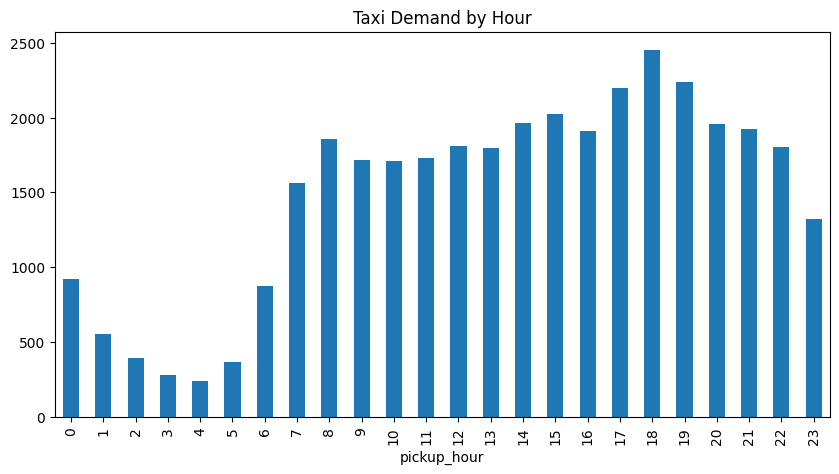

In [9]:
trip_demand = df['pickup_hour'].value_counts().sort_index()

trip_demand.plot(kind='bar', figsize=(10,5))
plt.title("Taxi Demand by Hour")
plt.show()

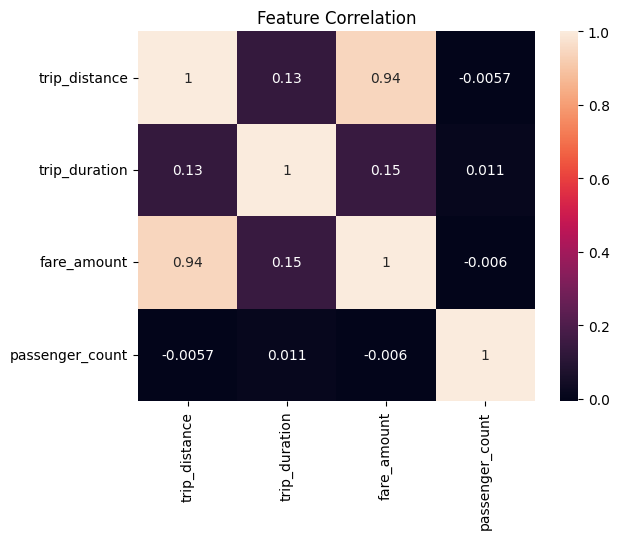

In [10]:
import seaborn as sns

corr = df[['trip_distance','trip_duration','fare_amount','passenger_count']].corr()

sns.heatmap(corr, annot=True)
plt.title("Feature Correlation")
plt.show()

In [11]:
features = df[['trip_distance','pickup_hour','pickup_day','passenger_count','trip_duration']]
target = df['fare_amount']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)

model.fit(X_train, y_train)

RandomForestRegressor()

In [14]:
predictions = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 0.6489098175438596
R2 Score: 0.8790569444110797


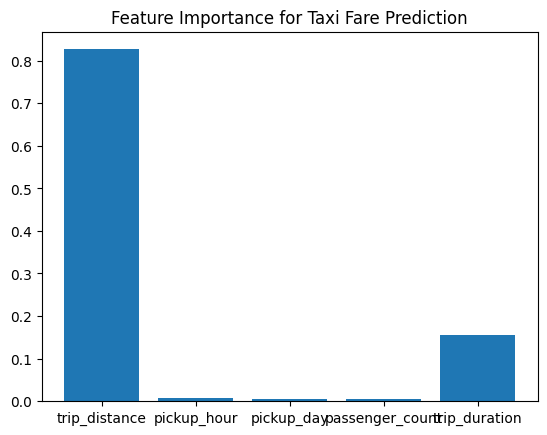

In [16]:
importance = model.feature_importances_
features_list = features.columns

plt.bar(features_list, importance)
plt.title("Feature Importance for Taxi Fare Prediction")
plt.show()

In [20]:
df.to_parquet("nyc_taxi_engineered.parquet")

In [18]:
import joblib

joblib.dump(model, "taxi_fare_model.pkl")

['taxi_fare_model.pkl']